# Used Car Price Prediction — A Machine Learning Walkthrough

This notebook walks through a complete machine learning pipeline to **predict the price of second-hand cars** based on their characteristics, using a real-world dataset.

It covers the following stages:
- **Exploratory Data Analysis (EDA):** cleaning, transforming, and understanding the data
- **Feature Engineering:** creating and selecting the most meaningful variables
- **Model Building:** training and comparing multiple regression models
- **Model Evaluation:** interpreting metrics to choose the best-performing approach

The goal is not just to get a prediction — it's to understand *why* each decision was made along the way.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer



sns.set_theme() # Setting seaborn style

In [7]:
cars = pd.read_csv('data/cars.csv', index_col=None)
cars.head()

,company,make,model,version,price,price_financed,fuel,year,kms,power,doors,shift,color,photos,is_professional,dealer,phone,province,publish_date,insert_date
0,9881BCDD5A0AD4733037B3FB25E69C3A,KIA,Carnival,KIA Carnival 2.9 CRDi VGT EX 5p.,4860,4860.0,Diésel,2007,221000,185.0,5.0,Manual,Beige (champagne),8,True,VM Motor,928493782,Las Palmas,2020-12-22 13:28:36,2020-12-25 00:00:00
1,9881BCDD5A0AD4733037B3FB25E69C3A,BMW,Serie 5,BMW Serie 5 4p.,1800,NaN,Diésel,2001,205000,NaN,4.0,Manual,Verde,0,False,3F128E570B3A9009D7B52A0523AF43DD,DBB2949B54A306BA299A791B860EEBF6,Tarragona,2020-12-14 07:02:22,2020-12-26 00:00:00
2,9881BCDD5A0AD4733037B3FB25E69C3A,FIAT,500,FIAT 500 1.2 8v 51kW 69CV Lounge 3p.,6490,6490.0,Gasolina,2017,75000,69.0,3.0,Manual,Negro,7,True,LAS PALMAS MOTOR,653895468,Las Palmas,2020-11-20 18:30:00,2020-12-08 00:00:00
3,9881BCDD5A0AD4733037B3FB25E69C3A,OPEL,Astra,OPEL Astra 3p.,5550,NaN,Diésel,2009,137000,NaN,3.0,Manual,Rojo,0,False,22003DEA67E7C5BE6022A29E677668BC,67990DA67E557C1D0C1B6D1DB731938C,Barcelona,2020-11-21 16:37:13,2020-11-24 00:00:00
4,9881BCDD5A0AD4733037B3FB25E69C3A,MERCEDES-BENZ,Clase C,MERCEDES-BENZ Clase C C 220 CDI AVANTGARDE 4p.,11990,11490.0,Diésel,2008,95000,170.0,4.0,Automático,Gris / Plata,21,True,Autos Lipiz,646179040,Madrid,2020-11-05 19:09:27,2020-12-01 00:00:00


# Exploratory Data Analysis (EDA)

Before building any model, we need to thoroughly understand our data. This phase involves:
- Identifying and removing duplicates
- Handling missing values
- Detecting and treating outliers
- Engineering new features
- Visualizing relationships between variables and the target

A solid EDA is often what separates a mediocre model from a good one.

In [8]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   company          5000 non-null   str    
 1   make             5000 non-null   str    
 2   model            4996 non-null   str    
 3   version          5000 non-null   str    
 4   price            5000 non-null   int64  
 5   price_financed   2268 non-null   float64
 6   fuel             4992 non-null   str    
 7   year             5000 non-null   int64  
 8   kms              5000 non-null   int64  
 9   power            4054 non-null   float64
 10  doors            4996 non-null   float64
 11  shift            4990 non-null   str    
 12  color            4942 non-null   str    
 13  photos           5000 non-null   int64  
 14  is_professional  5000 non-null   bool   
 15  dealer           5000 non-null   str    
 16  phone            5000 non-null   str    
 17  province         5000 non

## Duplicates

The first step is to identify and remove duplicate entries. Duplicates can distort the model by giving certain vehicles more weight than others — which is something we want to avoid.

In [9]:
cars.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

Rather than checking for exact row duplicates, we look for duplicates based on a **specific subset of key columns**. The reason: the same car might be listed on multiple platforms by the same seller — that doesn't make them different cars. From the model's perspective, they are still duplicates.

Removing them ensures every vehicle has equal weight during training.

In [10]:
print(cars.duplicated(subset=['make','model','version','year','kms','price']).sum())

36


There are **36 duplicate rows** in the dataset based on that subset of columns. We will drop them.

In [11]:
cars = cars.drop_duplicates(subset=['make','model','version','year','kms','price'])

In [12]:
print(cars.duplicated(subset=['make','model','version','year','kms','price']).sum())

0


## Missing Values

With duplicates handled, the next step is dealing with missing values. Nulls can cause errors, unexpected behavior, and degraded model performance. The right strategy depends on each column — a one-size-fits-all approach rarely works well.

Let's inspect which columns have missing values and how many.

In [13]:
cars.isnull().sum()

company               0
make                  0
model                 4
version               0
price                 0
price_financed     2714
fuel                  8
year                  0
kms                   0
power               941
doors                 4
shift                10
color                58
photos                0
is_professional       0
dealer                0
phone                 0
province              0
publish_date          0
insert_date           0
dtype: int64

Several columns contain missing values, each requiring a different treatment strategy.

**`model` column**

The number of null values is very small. Since dropping those rows won't have any noticeable effect on the dataset size, we simply remove them.

In [14]:
cars = cars.dropna(subset=['model'])

**`fuel`, `doors`, `shift`, `color`**

For these four columns, we fill missing values using the **mode** (the most frequent value).

Two reasons behind this decision:
1. The number of missing values is very small, so filling them won't introduce significant bias.
2. The mode is clearly dominant in all these columns — for example, the vast majority of cars are white, so adding a few dozen extra white entries has negligible impact.

> **Note:** The mode is preferred over the mean here because most of these variables are **categorical**. For `doors`, while numeric, the mode is still appropriate given the small number of missing entries.

In [15]:
cars['fuel'] = cars['fuel'].fillna(cars['fuel'].mode()[0])

cars['doors'] = cars['doors'].fillna(cars['doors'].mode()[0])

cars['shift'] = cars['shift'].fillna(cars['shift'].mode()[0])

cars['color'] = cars['color'].fillna(cars['color'].mode()[0])

# cars['color'].value_counts(dropna=False).head(20) -> reason for including 'color' here:
# the vast majority of entries are 'white' — adding ~50 more makes no noticeable difference.

**`power`**

Engine power is likely an important predictor of price, but it has a significant number of missing values. Two imputation strategies are worth exploring:
- `SimpleImputer(strategy='median')` — robust to outliers, fast and straightforward
- `KNNImputer` — estimates missing values based on similar rows in the dataset, potentially more precise

We use `SimpleImputer` with the median as our default. Results using `KNNImputer` are discussed in the model observations sections.

In [16]:
cars['power'].describe()

count    4023.000000
mean      146.201839
std        70.897542
min        38.000000
25%       109.000000
50%       130.000000
75%       160.000000
max       670.000000
Name: power, dtype: float64

In [17]:
cars['power'].isna().sum()

np.int64(937)

In [18]:
imp = SimpleImputer(strategy='median')
cars['power'] = imp.fit_transform(cars[['power']])

# imp = KNNImputer(n_neighbors=10)
# cars[['power']] = imp.fit_transform(cars[['power']])

In [19]:
cars['power'].isna().sum()

np.int64(0)

**`price_financed`**

This column contains the financed price of the car. It has an excessive number of missing values and — more importantly — it doesn't have a direct causal relationship with the sale price we are predicting. We drop it entirely.

> **Alternative worth exploring:** Converting this to a binary feature (1 = financing available, 0 = not) and testing whether it influences price.

In [20]:
cars = cars.drop(columns=['price_financed'])

In [21]:
cars.isnull().sum()

company            0
make               0
model              0
version            0
price              0
fuel               0
year               0
kms                0
power              0
doors              0
shift              0
color              0
photos             0
is_professional    0
dealer             0
phone              0
province           0
publish_date       0
insert_date        0
dtype: int64

## Feature Engineering

### Dropping Irrelevant Columns

Some columns clearly add no predictive value and would only introduce noise. Here's what we remove and why:

| Column | Reason for dropping |
|---|---|
| `company` | Looks like an internal ID with no relation to price |
| `dealer` | Dealer identity ideally shouldn't affect price (though it *could* be tested) |
| `phone` | Unique identifier, completely irrelevant |
| `color` | Too noisy — the same color appears as "white", "WHITE", "White (BLANCO)", etc. A proper normalization pass could recover this column |
| `photos` | No predictive value |
| `year`, `publish_date`, `insert_date` | Redundant once we create `car_age` |

### Creating New Features

**`car_age`**: Instead of the raw year, we derive the car's age directly. This is more semantically meaningful and linear in relation to price — a 10-year-old car is 10 years old regardless of when the data was collected.

> **Optional extension:** A `kms_per_year` ratio could add additional signal as a derived feature.

In [22]:
cars = cars.drop(columns=['company', 'dealer', 'phone','color','photos'])

cars['publish_date'] = pd.to_datetime(cars['publish_date'], errors='coerce')
cars['insert_date'] = pd.to_datetime(cars['insert_date'], errors='coerce')

cars['car_age'] = cars['insert_date'].dt.year - cars['year']

cars.loc[cars['car_age'] < 0, 'car_age'] = 0


cars = cars.drop(columns=['publish_date', 'insert_date','year'])

### Outlier Detection

Before fitting any model, we check for absurd values in our numerical columns that may stem from data entry errors. These would skew the model and hurt its generalization ability.

In [23]:
cars[['price', 'kms', 'power','car_age']].describe()

,price,kms,power,car_age
count,4960.000000,4.960000e+03,4960.000000,4960.000000
mean,15053.953629,1.165958e+05,143.141129,8.169355
std,15421.856253,9.831040e+04,64.163416,6.694734
min,300.000000,0.000000e+00,38.000000,0.000000
25%,5000.000000,3.454650e+04,110.000000,3.000000
50%,11500.000000,1.000000e+05,130.000000,6.000000
75%,19990.000000,1.800000e+05,150.000000,13.000000
max,319900.000000,1.820000e+06,670.000000,49.000000


Two things stand out:

- **Minimum price: €300** — this could be a legitimate old car at very low value, but worth investigating.
- **Maximum mileage: 1,820,000 km** — almost certainly a data entry error.

In [24]:
cars.sort_values(by='price', ascending=True).head(10)

,make,model,version,price,fuel,kms,power,doors,shift,is_professional,province,car_age
965,PEUGEOT,Partner,PEUGEOT Partner 5p.,300,Diésel,300000,130.0,5.0,Manual,False,Cádiz,19
1559,PEUGEOT,106,PEUGEOT 106 LONG BEACH 1.1 3p.,300,Gasolina,366567,60.0,3.0,Manual,False,Barcelona,23
4154,BMW,Serie 3,BMW Serie 3 5p.,300,Diésel,220000,130.0,5.0,Manual,False,Madrid,19
3918,VOLKSWAGEN,Golf,VOLKSWAGEN Golf 1.9TDI GT 3p.,300,Diésel,330000,110.0,3.0,Manual,False,Barcelona,25
214,RENAULT,Clio Campus,RENAULT Clio Campus 3p.,300,Gasolina,280000,130.0,3.0,Manual,False,Tenerife,24
3369,RENAULT,Grand Espace,RENAULT Grand Espace 5p.,300,Diésel,308000,130.0,5.0,Automático,False,Navarra,16
2945,PEUGEOT,306,PEUGEOT 306 5p.,300,Diésel,250000,130.0,5.0,Manual,False,Guipúzcoa,19
2210,RENAULT,19,RENAULT 19 R19 CHAMADE 1.4 GTS 4p.,350,Gasolina,311000,80.0,4.0,Manual,False,Las Palmas,30
3762,OPEL,Corsa,OPEL Corsa 3p.,400,Gasolina,200000,130.0,3.0,Manual,False,Las Palmas,30
3411,RENAULT,Grand Scénic,RENAULT,400,Diésel,365000,130.0,5.0,Manual,False,Madrid,17


On closer inspection, the cheapest entries are very old, high-mileage, low-range vehicles. The €300 price makes sense in context — these are legitimate entries, not errors.

In [25]:
cars.sort_values(by='kms', ascending=False).head(10)

,make,model,version,price,fuel,kms,power,doors,shift,is_professional,province,car_age
3442,ROVER,25,ROVER 25 3p.,550,Gasolina,1820000,130.0,3.0,Manual,False,Las Palmas,20
920,FIAT,Grande Punto,FIAT Grande Punto 5p.,4200,Diésel,1400000,130.0,5.0,Manual,False,La Rioja,14
1083,MERCEDES-BENZ,Sprinter,MERCEDES-BENZ Sprinter 2p.,4500,Diésel,760000,130.0,2.0,Manual,False,Córdoba,11
1465,RENAULT,Master,RENAULT Master Furgon 3500 Largo Hiperelev. 3....,5999,Diésel,600000,136.0,4.0,Manual,False,Alicante,14
4160,BMW,Serie 5,BMW Serie 5 5p.,4600,Diésel,560000,130.0,5.0,Manual,False,Almería,13
1435,RENAULT,Trafic,RENAULT Trafic Passenger Combi 9 29 L.Normal 2...,5800,Diésel,520000,115.0,4.0,Manual,False,Madrid,12
1087,SKODA,Octavia,SKODA Octavia 1.9 GLX TDI 5p.,590,Diésel,480000,90.0,5.0,Manual,False,Zamora,21
353,MERCEDES-BENZ,Clase C,MERCEDES-BENZ Clase C C 220 CDI AVANTGARDE 4p.,3900,Diésel,480000,143.0,4.0,Manual,True,A Coruña,19
1444,PEUGEOT,505,PEUGEOT 505 505 GTD 2.5 TURBO 4p.,3000,Diésel,450000,95.0,4.0,Manual,False,Ciudad Real,38
1324,TOYOTA,Land Cruiser,TOYOTA Land Cruiser 3.0 D4D VX 5p.,22000,Diésel,443000,166.0,5.0,Manual,False,Madrid,15


There are 2 cars with over 900,000 km — almost certainly data entry errors. We remove them.

In [26]:
cars = cars[cars['kms'] < 900000]

In [27]:
cars.describe()

,price,kms,power,doors,car_age
count,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000
mean,15059.068173,115993.373739,143.146430,4.506656,8.165793
std,15422.820069,93545.908728,64.175816,0.871775,6.693463
min,300.000000,0.000000,38.000000,2.000000,0.000000
25%,5000.000000,34515.500000,110.000000,4.000000,3.000000
50%,11500.000000,100000.000000,130.000000,5.000000,6.000000
75%,19990.000000,180000.000000,150.000000,5.000000,13.000000
max,319900.000000,760000.000000,670.000000,5.000000,49.000000


We can also apply the **IQR (Interquartile Range)** method to systematically detect and remove outliers across all numerical columns. This is a standard statistical approach: values that fall significantly below Q1 or above Q3 (typically beyond 1.5× the IQR) are flagged as outliers.

In [28]:
def del_outliers_quartile(df, cols, k=1.5):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        low = Q1 - k * IQR
        high = Q3 + k * IQR

        df_clean = df_clean[(df_clean[col] >= low) & (df_clean[col] <= high)]

    return df_clean


num_cols = ['price', 'kms', 'power', 'car_age']
cars = del_outliers_quartile(cars, num_cols)

### Checking Cardinality of Categorical Columns

Let's inspect the number of unique values in `make`, `model`, and `version` to determine whether all three are genuinely useful or if any creates too much noise.

In [29]:
cars['make'].nunique(), cars['model'].nunique(), cars['version'].nunique()


(49, 511, 3035)

In [30]:
cars['version'].value_counts().head(10)

version
VOLKSWAGEN              37
BMW                     36
OPEL                    24
FORD                    22
AUDI                    22
BMW X1 sDrive18d 5p.    20
RENAULT                 17
PEUGEOT                 16
SEAT                    15
SEAT Ibiza  3p.         14
Name: count, dtype: int64

The `version` column is far too granular — it often just repeats content already found in `make` or `model`, with very little consistency across entries. We drop it to reduce noise.

In [31]:
cars = cars.drop(columns=['version'])

## Visualizations

Now that the data is clean and transformed, let's plot the relationships between features and price. This helps validate our preprocessing decisions and ensures the data structure makes sense before we start modeling.

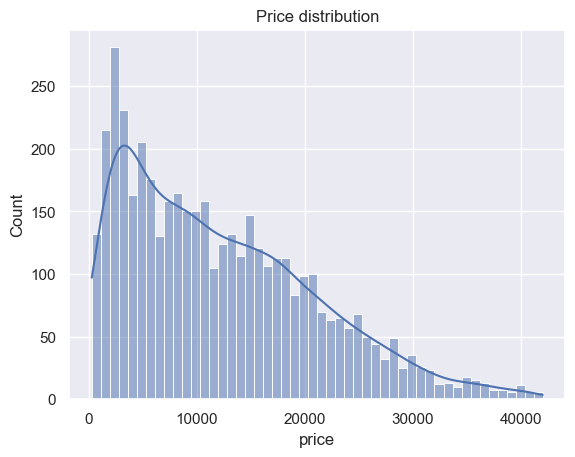

In [32]:
sns.histplot(cars['price'], bins=50, kde=True)
plt.title("Price distribution")
plt.show()

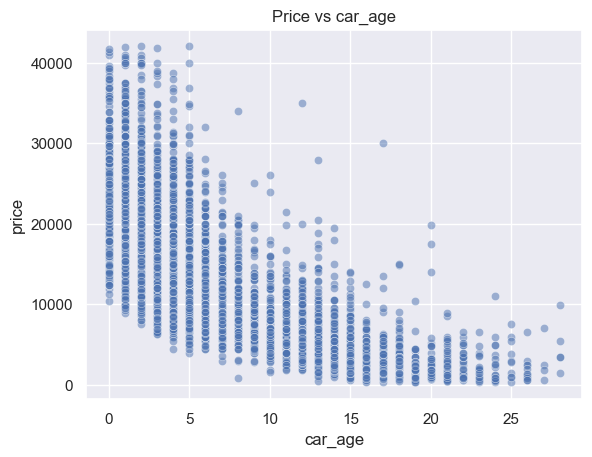

In [33]:
sns.scatterplot(x='car_age', y='price', data=cars, alpha=0.5)
plt.title("Price vs car_age")
plt.show()


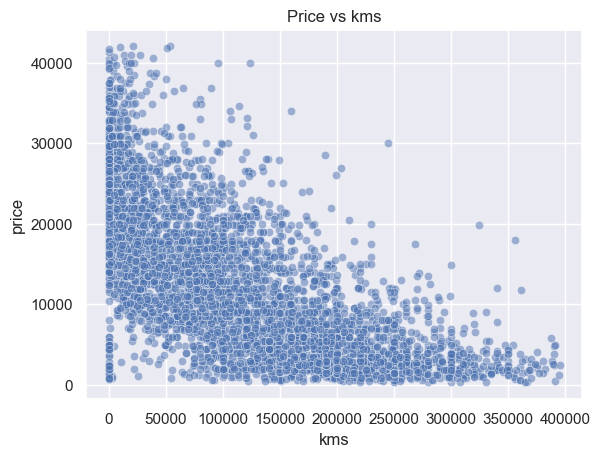

In [34]:
sns.scatterplot(x='kms', y='price', data=cars, alpha=0.5)
plt.title("Price vs kms")
plt.show()


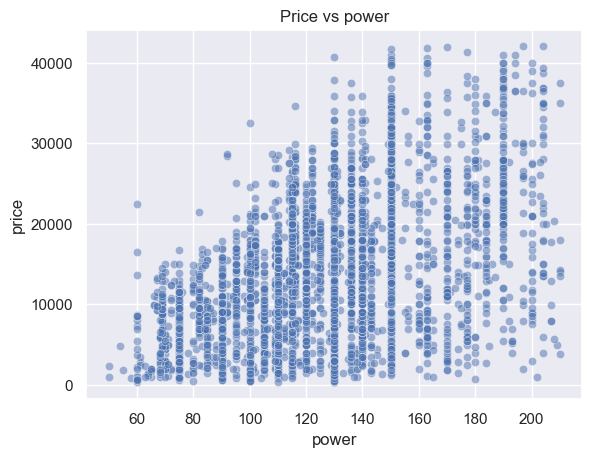

In [35]:
sns.scatterplot(x='power', y='price', data=cars, alpha=0.5)
plt.title("Price vs power")
plt.show()


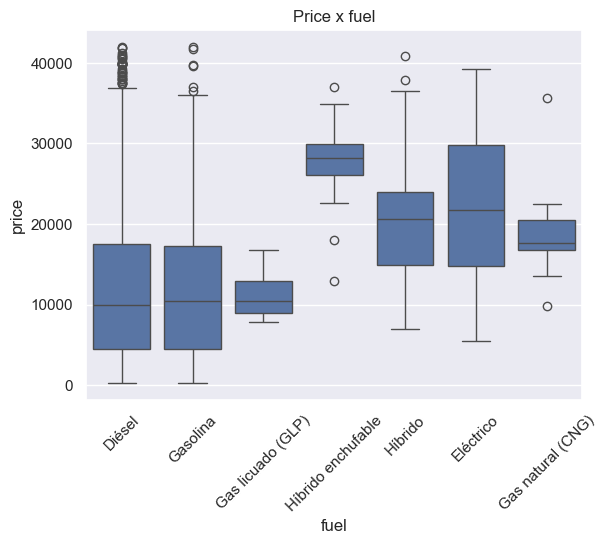

In [36]:
sns.boxplot(x='fuel', y='price', data=cars)
plt.title("Price x fuel")
plt.xticks(rotation=45)
plt.show()


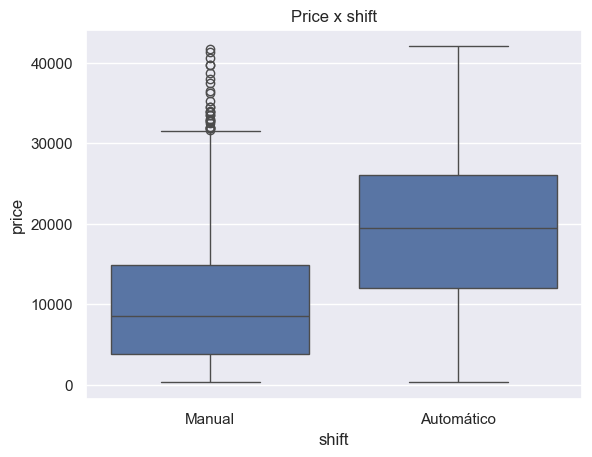

In [37]:
sns.boxplot(x='shift', y='price', data=cars)
plt.title("Price x shift")
plt.show()


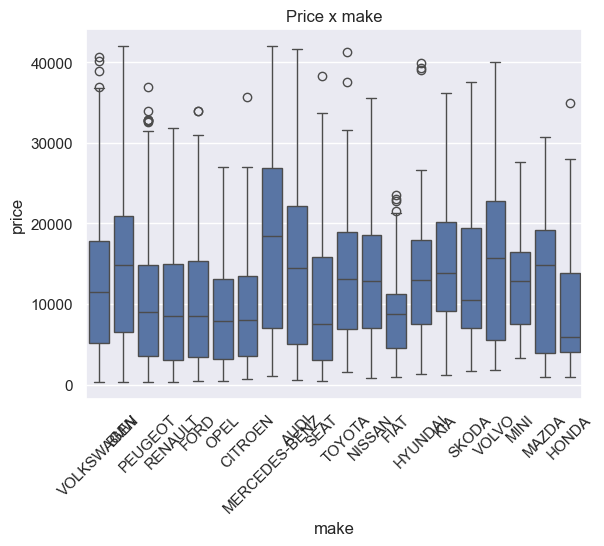

In [38]:
top_makes = cars['make'].value_counts().head(20).index
sns.boxplot(data=cars[cars['make'].isin(top_makes)],
            x='make', y='price', order=top_makes)
plt.xticks(rotation=45); plt.title('Price x make'); plt.show()


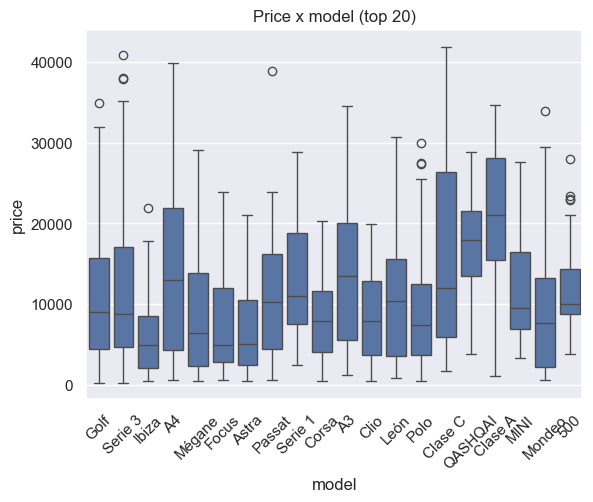

In [39]:
top_models = cars['model'].value_counts().head(20).index
sns.boxplot(data=cars[cars['model'].isin(top_models)],
            x='model', y='price', order=top_models)
plt.xticks(rotation=45); plt.title('Price x model (top 20)'); plt.show()


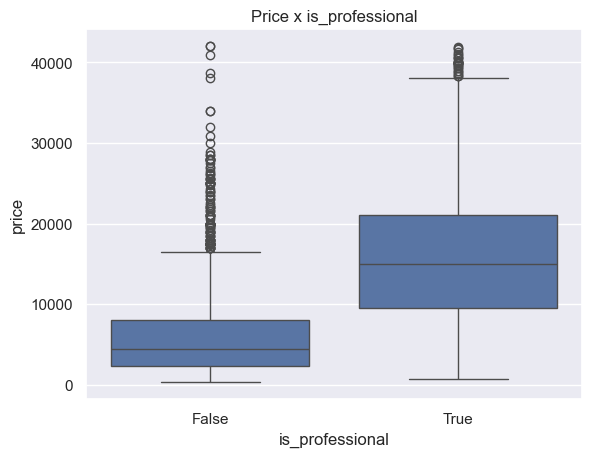

In [40]:
sns.boxplot(data=cars, x='is_professional', y='price')
plt.title('Price x is_professional'); plt.show()


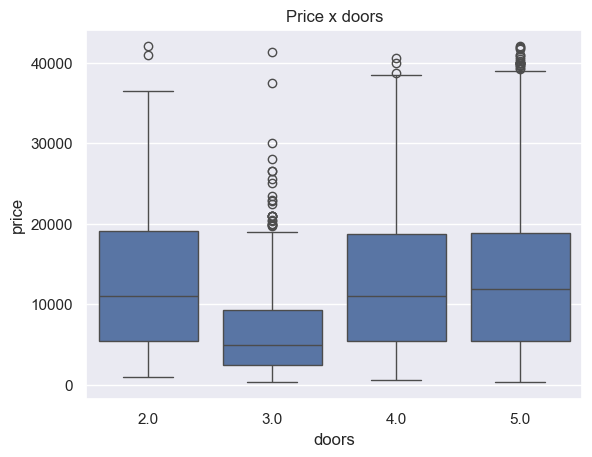

In [41]:
sns.boxplot(data=cars, x='doors', y='price', order=sorted(cars['doors'].unique()))
plt.title('Price x doors'); plt.show()


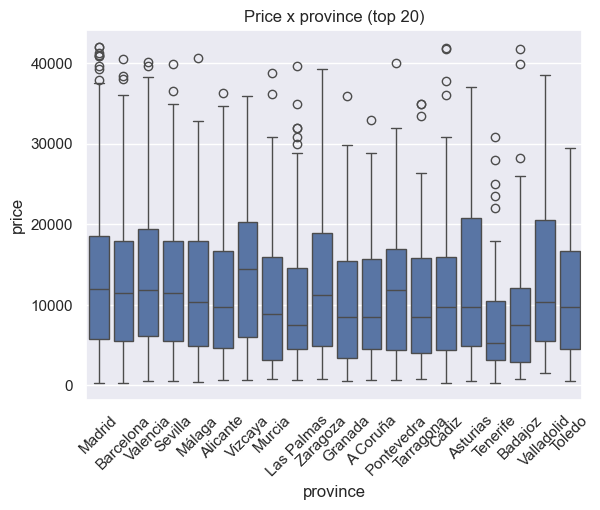

In [42]:
top_prov = cars['province'].value_counts().head(20).index
sns.boxplot(data=cars[cars['province'].isin(top_prov)],
            x='province', y='price', order=top_prov)
plt.xticks(rotation=45); plt.title('Price x province (top 20)'); plt.show()


**Key takeaways from the visualizations:**

- The average car price is around €20,000
- Newer cars tend to be more expensive (as expected)
- Lower mileage correlates with higher price
- Higher engine power correlates with higher price
- Plug-in hybrids and electric cars tend to be pricier, but the effect is relatively small — worth testing the model with and without this variable
- Automatic transmission cars are generally more expensive, though the effect is moderate
- Brand and model clearly influence price — luxury brands command significantly higher prices
- Listings from professional sellers tend to be higher-priced
- `doors` and `province` show very little price variation — we keep them for now but may revisit

Since `shift` has only two values (manual / automatic), we convert it to a binary column `is_automatic`. We also cast `is_professional` to 0/1.

In [43]:
cars['is_automatic'] = (cars['shift'].str.lower().str.strip() == 'automático').astype(int)
cars['is_professional'] = cars['is_professional'].astype(int)

cars = cars.drop(columns=['shift'])


---

# Models

## Simple Linear Regression

A simple linear regression uses **only one feature** to predict the target variable. While this is not a realistic pricing model on its own — car prices depend on many factors simultaneously — it is a great diagnostic tool to understand the **individual predictive contribution of each variable**.

For each feature we will look at:
- **Coefficient:** how the target changes per unit increase in this feature
- **Intercept:** the baseline predicted value when the feature equals zero
- **R²:** how much of the price variance this single variable explains
- **MAE (Mean Absolute Error):** average prediction error in euros

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

Coefficient: -1055.3620221449464
Intercept: 20762.662738288822
R² (test): 0.5722645202779737
MAE (test): 4374.916174593204


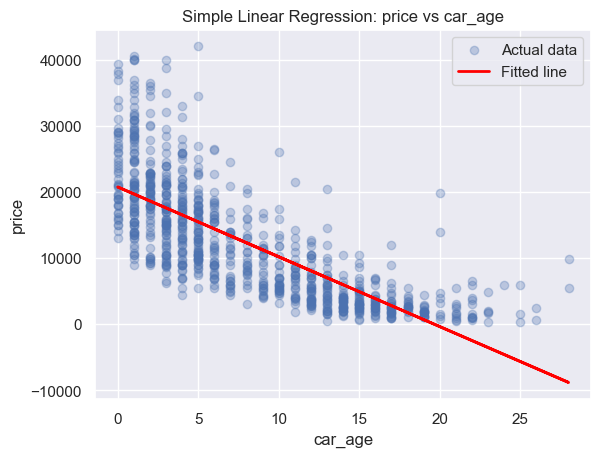

In [45]:
# Independent (X) and dependent (y) variables
X = cars[['car_age']]
y = cars['price']

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))

# Plot
plt.scatter(X_test, y_test, alpha=0.3, label="Actual data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Fitted line")
plt.xlabel("car_age")
plt.ylabel("price")
plt.title("Simple Linear Regression: price vs car_age")
plt.legend()
plt.show()

**What can we learn from this?**

- **Coefficient:** For every additional year of age, the average car price drops by ~€1,160.
- **Intercept:** A brand-new car (age = 0) has a predicted average price of ~€24,760.
- **R² = 0.34:** Car age alone explains 34% of the price variance — a meaningful single-variable signal.
- **MAE:** On average, predictions are off by ~€6,800 — expected when relying on just one feature.

Coefficient: -0.0647256373699808
Intercept: 19727.190231474317
R² (test): 0.41557416301997463
MAE (test): 5274.305368985207


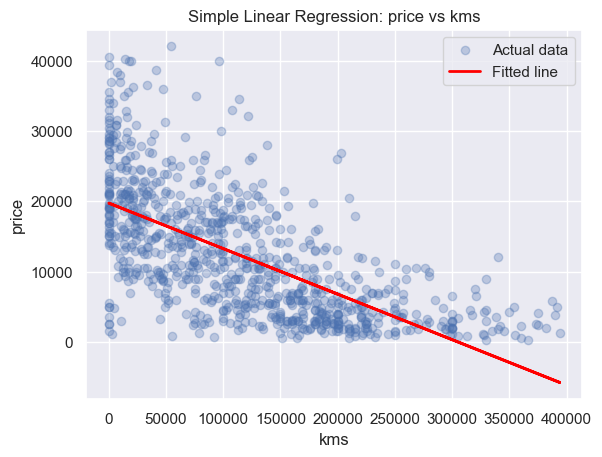

In [46]:
X = cars[['kms']]
y = cars['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))

plt.scatter(X_test, y_test, alpha=0.3, label="Actual data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Fitted line")
plt.xlabel("kms")
plt.ylabel("price")
plt.title("Simple Linear Regression: price vs kms")
plt.legend()
plt.show()

**What can we learn from this?**

- **Coefficient:** Every extra kilometer reduces price by €0.079. Scaled up: every 1,000 km costs about €80 in value. This makes intuitive sense — 1,000 km is relatively small on a car's lifespan. Of course, this should be interpreted carefully: a high-mileage car doesn't literally approach €0 in value.
- **Intercept:** A car with 0 km is predicted to cost ~€24,456 — very close to the `car_age` intercept, which is reassuring.
- **R² = 0.29:** Mileage explains 29% of price variance. Significant, but slightly less than age.
- **MAE:** On average, predictions are off by ~€7,329 — consistent with the other single-variable models.

Coefficient: 116.62476678020295
Intercept: -2584.346668240609
R² (test): 0.18242235859260714
MAE (test): 6700.285736521791


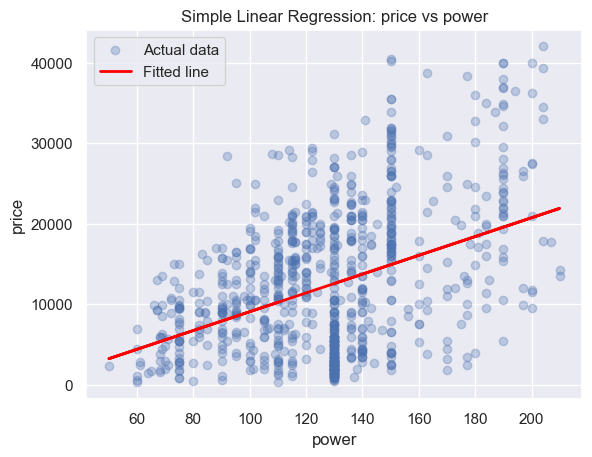

In [47]:
X = cars[['power']]
y = cars['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))

plt.scatter(X_test, y_test, alpha=0.3, label="Actual data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Fitted line")
plt.xlabel("power")
plt.ylabel("price")
plt.title("Simple Linear Regression: price vs power")
plt.legend()
plt.show()

**What can we learn from this?**

- **Coefficient:** Each additional unit of engine power (CV/hp) increases the predicted price by ~€170 on average. This makes sense — high-performance cars are typically much more expensive.
- **Intercept:** Not meaningful here — a car with 0 CV doesn't exist.
- **R² = 0.404:** Power is the strongest individual predictor so far, explaining ~40% of price variance.
- **MAE:** On average, predictions are off by ~€7,631 — consistent with the other single-variable models.

Coefficient: 1656.9618898685412
Intercept: 4688.155963285264
R² (test): 0.021474480808107765
MAE (test): 7205.491323727595


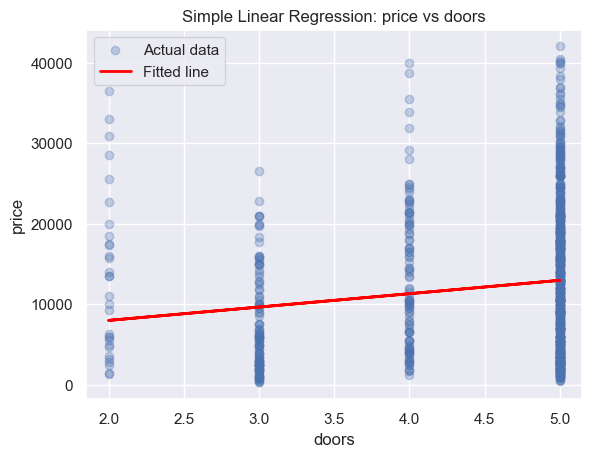

In [48]:
X = cars[['doors']]
y = cars['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))

plt.scatter(X_test, y_test, alpha=0.3, label="Actual data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Fitted line")
plt.xlabel("doors")
plt.ylabel("price")
plt.title("Simple Linear Regression: price vs doors")
plt.legend()
plt.show()

**What can we learn from this?**

With an R² close to 0, `doors` has virtually no linear relationship with price on its own. We can already rule it out as a meaningful standalone predictor. It may still contribute marginal signal within a multi-variable model, which we will explore next.

Coefficient: 9569.168515302188
R² (test): 0.2989741132657917
MAE (test): 5705.04452168059


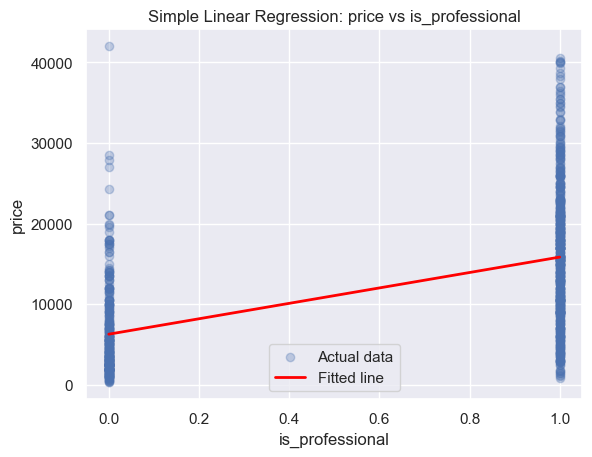

In [49]:
X = cars[['is_professional']]
y = cars['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))

plt.scatter(X_test, y_test, alpha=0.3, label="Actual data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Fitted line")
plt.xlabel("is_professional")
plt.ylabel("price")
plt.title("Simple Linear Regression: price vs is_professional")
plt.legend()
plt.show()

**What can we learn from this?**

- **Coefficient:** The average price difference between professional and non-professional listings.
- **R² = 0.16:** Professional status explains about 16% of price variance — a modest but non-negligible signal.
- **MAE:** In line with the other single-variable models.

Coefficient: 8953.034001284941
R² (test): 0.2072828373806599
MAE (test): 6420.774284356699


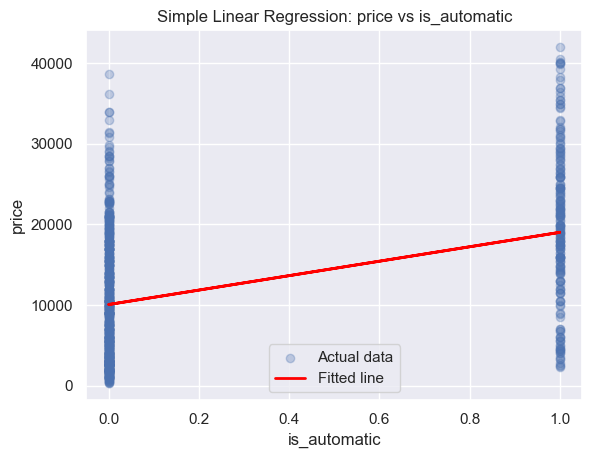

In [50]:
X = cars[['is_automatic']]
y = cars['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))

plt.scatter(X_test, y_test, alpha=0.3, label="Actual data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Fitted line")
plt.xlabel("is_automatic")
plt.ylabel("price")
plt.title("Simple Linear Regression: price vs is_automatic")
plt.legend()
plt.show()

**What can we learn from this?**

- **Coefficient:** Automatic cars cost on average ~€16,000 more than manual ones.
- **R² = 0.24:** Transmission type explains about 24% of price variance — a meaningful signal.
- **MAE:** In line with the other single-variable models.

In [51]:
X = pd.get_dummies(cars[['fuel']], drop_first=True)
y = cars['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coeficiente:", model.coef_[0])
print("R² (test):", r2_score(y_test, y_pred))
print("MAE (test):", mean_absolute_error(y_test, y_pred))


Coeficiente: 9558.342251180522
R² (test): 0.061029248335175645
MAE (test): 7102.933873392056


**What can we learn from this?**

With an R² of only ~8%, `fuel` type has limited standalone predictive power. However, it may contribute meaningfully when combined with other features in a multi-variable model.

## Multiple Linear Regression

Now we combine all relevant features into a single model. Unlike the simple regressions above — which only looked at one variable at a time — multiple linear regression allows the model to **capture the combined effect of all features simultaneously**.

This is where the real predictive power emerges.

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
# ---- 1) Feature selection ----
features = ['car_age','kms','power','is_automatic','fuel','make','model','doors']
X = cars[features].copy()
y = cars['price'].copy()

# ---- 2) One-hot encoding for categorical columns ----
cat_cols = ['fuel','make','model']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)


# ---- 3) Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ---- 4) Train model ----
lr = LinearRegression()
lr.fit(X_train, y_train)

# ---- 5) Evaluation ----
y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Intercept:", lr.intercept_)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

y_pred_train = lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)

print("R² (train):", r2_train)

Intercept: 16072.459753426112
MAE: 2405.976864595534
MSE: 10989128.920386428
RMSE: 3314.985508322235
R²: 0.86156606938572
R² (train): 0.9021785960944837


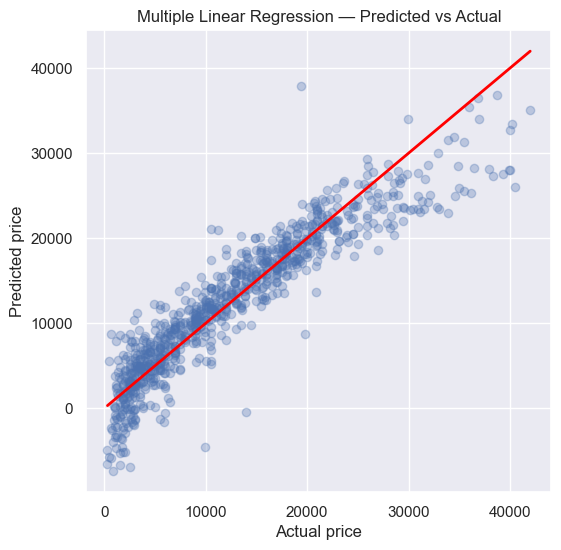

In [53]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Multiple Linear Regression — Predicted vs Actual")
plt.show()

**Results**

- **R² = 0.861 (test) / 0.902 (train):** The model explains ~86% of price variance on unseen data. This is a strong result for a general-purpose model, with no severe overfitting.
- **MAE and RMSE** are relatively low and appropriate for the price range in this dataset.

**Conclusion:** Combining all features gives us a significantly better model than any single-variable regression.

---

**Additional experiments and observations**

- **Without removing outliers:** R² drops to 0.79 (test) / 0.87 (train) — the model overfits trying to fit extreme values.
- **Removing only cars with >900,000 km:** R² = 0.83 (test) / 0.86 (train) — removes clearly erroneous data while preserving "exclusive" high-value cars that would otherwise be lost.
- **Using only the top 3 variables** (`car_age`, `kms`, `power`) already yields R² = 0.75 — a surprisingly strong baseline with far fewer features.
- **`doors`** makes almost no difference — negligible signal either way.
- **`fuel`** removal drops R² by ~0.005 — small but slightly more noticeable than `doors`.
- **`model`** is highly important — removing it drops R² (test) to 0.81 / R² (train) to 0.82. **`make`** is more dispensable, dropping R² (test) only to 0.85.
- **`KNNImputer` for `power`** yields R² = 0.85 (test) / 0.90 (train) — slightly worse than `SimpleImputer`.
- **`is_professional`** improves R² from 0.861 to 0.864 — small gain, worth keeping.
- **`province`** slightly hurts the model — negligible impact.

---

> **Note:** All subsequent models preserve the same preprocessing decisions as above — not because this is necessarily optimal, but because consistency makes model comparisons fair and easier to follow.

> **What comes next — Regularized Linear Models**
>
> The next two models (LASSO and Ridge) are **regularized** variants of linear regression. They work the same way as multiple linear regression, but add a **penalty term** to the loss function that discourages the model from assigning very large coefficients to any single feature.
>
> This helps prevent overfitting, especially when the number of features is large — as is the case here after one-hot encoding `make` and `model`.
>
> - **LASSO (L1 regularization):** drives some coefficients exactly to zero, effectively performing automatic feature selection.
> - **Ridge (L2 regularization):** shrinks all coefficients toward zero without eliminating any of them, producing a more stable model.

## LASSO Regression

In [54]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# ---- 1) Feature selection ----
lasso_features = ['car_age','kms','power','is_automatic','fuel','make','model','doors']

X_lasso = cars[lasso_features].copy()
y_lasso = cars['price'].copy()

# ---- 2) One-hot encoding ----
cat_cols_lasso = ['fuel','make','model']
X_lasso = pd.get_dummies(X_lasso, columns=cat_cols_lasso, drop_first=True)

# ---- 3) Split ----
X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(
    X_lasso, y_lasso, test_size=0.2, random_state=0
)

# ---- 4) LASSO model with cross-validation ----
lasso = LassoCV(
    alphas=[0.001, 0.01, 0.1, 1, 10],
    cv=5,
    random_state=0,
    max_iter=50000
)

lasso.fit(X_train_lasso, y_train_lasso)

# ---- 5) Evaluation ----
y_pred_lasso = lasso.predict(X_test_lasso)
y_pred_train_lasso = lasso.predict(X_train_lasso)


mae_lasso = mean_absolute_error(y_test_lasso, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_lasso, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_lasso, y_pred_lasso)
r2_train_lasso = r2_score(y_train_lasso, y_pred_train_lasso)

print("Best alpha:", lasso.alpha_)
print("MAE (test):", mae_lasso)
print("RMSE (test):", rmse_lasso)
print("R² (test):", r2_lasso)
print("R² (train):", r2_train_lasso)

coefs_lasso = pd.Series(lasso.coef_, index=X_train_lasso.columns)
print("\nNon-zero coefficients:", (coefs_lasso != 0).sum())

Best alpha: 1.0
MAE (test): 2438.2339540422854
RMSE (test): 3347.3677989861767
R² (test): 0.8588482880721893
R² (train): 0.8944761726047652

Non-zero coefficients: 357


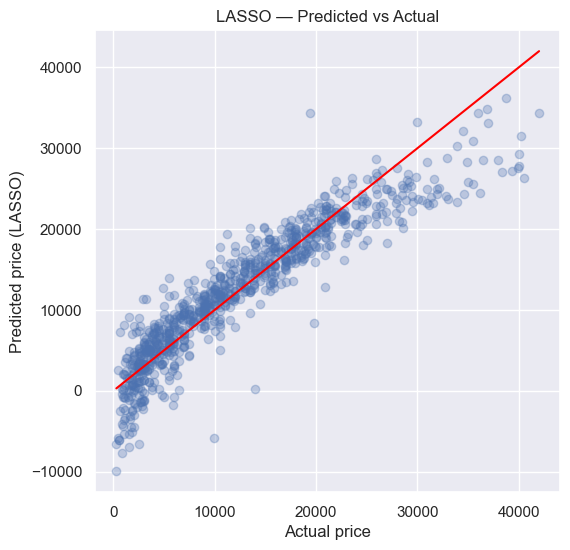

In [55]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_lasso, y_pred_lasso, alpha=0.3)
plt.plot([y_test_lasso.min(), y_test_lasso.max()],
         [y_test_lasso.min(), y_test_lasso.max()],
         color='red')

plt.xlabel("Actual price")
plt.ylabel("Predicted price (LASSO)")
plt.title("LASSO — Predicted vs Actual")
plt.show()

**Results (LASSO)**

- **R² = 0.858 (test) / 0.894 (train):** Nearly identical to standard multiple regression — regularization doesn't hurt predictive power here.
- **MAE and RMSE:** Slightly higher than the multiple regression model, but still well within an acceptable range.
- **Non-zero coefficients:** LASSO retained **357 features** with non-zero coefficients. Under the applied penalty, the model selects these as the most relevant and silences the rest — slightly reducing noise compared to the standard linear model.
- **Best alpha = 1.0:** A mild regularization — enough to trim noise without distorting the overall fit.

**Conclusion:** LASSO delivers accuracy very close to plain multiple regression with a slightly more compact model.

---

**Additional experiments and observations**

- **Without removing outliers:** R² = 0.80 (test) / 0.86 (train)
- **Removing only cars with >900,000 km:** Results nearly identical to the standard multiple regression (0.83/0.86)
- **Without categorical features:** Model trains near-instantly but R² drops to 0.77/0.78. Keeping only `fuel` gives 0.78/0.786. Keeping only `model` gives 0.81/0.82 — still a reasonably reliable model.
- **`KNNImputer`** yields R² = 0.85 (test) / 0.89 (train) — slightly worse than `SimpleImputer`.
- **`is_professional`** barely changes R² but slightly improves it — worth keeping.
- **`province`** slightly hurts the model — negligible impact.

## Ridge Regression

In [56]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ---- 1) Feature selection ----
ridge_features = ['car_age','kms','power','is_automatic','fuel','make','model','doors']

X_ridge = cars[ridge_features].copy()
y_ridge = cars['price'].copy()

# ---- 2) One-hot encoding ----
cat_cols_ridge = ['fuel','make','model']
X_ridge = pd.get_dummies(X_ridge, columns=cat_cols_ridge, drop_first=True)

# ---- 3) Split ----
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(
    X_ridge, y_ridge, test_size=0.2, random_state=0
)

# ---- 4) Ridge model with cross-validation ----
ridge = RidgeCV(
    alphas=[0.001, 0.01, 0.1, 1, 10, 100],
    cv=5
)

ridge.fit(X_train_ridge, y_train_ridge)

# ---- 5) Evaluation ----
y_pred_ridge = ridge.predict(X_test_ridge)
y_pred_train_ridge = ridge.predict(X_train_ridge)

mae_ridge = mean_absolute_error(y_test_ridge, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_ridge, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_ridge, y_pred_ridge)
r2_train_ridge = r2_score(y_train_ridge, y_pred_train_ridge)

print("Best alpha:", ridge.alpha_)
print("MAE (test):", mae_ridge)
print("RMSE (test):", rmse_ridge)
print("R² (test):", r2_ridge)
print("R² (train):", r2_train_ridge)

C:\Users\21ale\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.7041221126363476e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\21ale\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.706833383388318e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\21ale\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.630679813339247e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\21ale\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6694446399552056e-17.
  return linalg.solve(A, Xy, assume

Best alpha: 1.0
MAE (test): 2415.1468816862152
RMSE (test): 3279.8023948091322
R² (test): 0.8644889722572553
R² (train): 0.8957953103014756


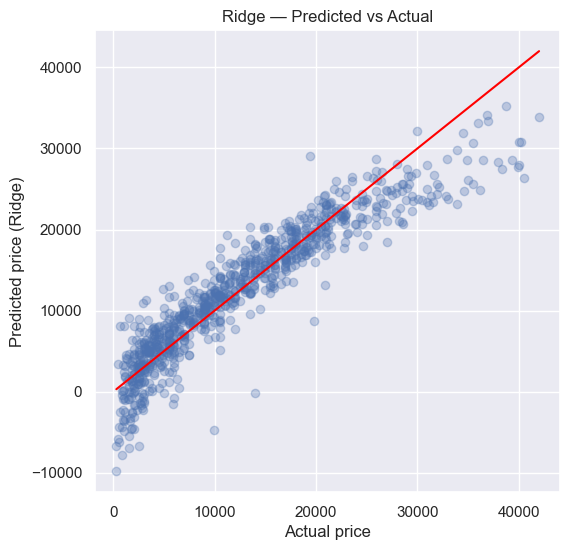

In [57]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual price")
plt.ylabel("Predicted price (Ridge)")
plt.title("Ridge — Predicted vs Actual")
plt.show()

**Results (Ridge)**

- **R² = 0.864 (test) / 0.895 (train):** Very stable performance, with a small gap between train and test — no signs of overfitting.
- **MAE and RMSE:** Slightly better than both the standard multiple regression and LASSO. This is consistent with Ridge being especially robust when there are many correlated features — exactly our case with all the `make` and `model` dummy variables.
- **Best alpha = 1.0:** Same mild regularization as LASSO.
- Ridge is also noticeably **faster to train** than LASSO.

**Conclusion:** Ridge achieves slightly better accuracy than LASSO and is the most stable and robust model for this dataset.

---

**Additional experiments and observations**

- **Without removing outliers:** R² = 0.81 (test) / 0.86 (train)
- **Removing only cars with >900,000 km:** R² = 0.83 (test) / 0.85 (train)
- **Without `model` and `make`:** R² ≈ 0.78/0.78. Keeping only `model` gives 0.85/0.89; keeping only `make` gives 0.81/0.82 — a pattern very similar to LASSO, but consistently equal or faster.
- **`KNNImputer` vs `SimpleImputer`:** Uniquely among all models tested, Ridge shows **no noticeable difference** between the two strategies — R² = 0.86/0.89 in both cases.
- **`is_professional`** slightly improves the model — worth keeping.
- **`province`** slightly hurts the model — negligible impact.

## Polynomial Regression

In [58]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ---- 1) Feature selection ----
poly_features = ['car_age','kms','power','is_automatic']
X_poly = cars[poly_features].copy()
y_poly = cars['price'].copy()

# ---- 2) Split ----
X_train_poly_raw, X_test_poly_raw, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=0
)

# ---- 3) Polynomial transformation ----
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_poly_raw)
X_test_poly = poly.transform(X_test_poly_raw)

# ---- 4) Train polynomial model ----
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

# ---- 5) Evaluation ----
y_pred_poly_test = model_poly.predict(X_test_poly)
y_pred_poly_train = model_poly.predict(X_train_poly)

mae_poly = mean_absolute_error(y_test_poly, y_pred_poly_test)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly_test)
rmse_poly = np.sqrt(mse_poly)
r2_poly_test = r2_score(y_test_poly, y_pred_poly_test)
r2_poly_train = r2_score(y_train_poly, y_pred_poly_train)

print("MAE (test):", mae_poly)
print("RMSE (test):", rmse_poly)
print("R² (test):", r2_poly_test)
print("R² (train):", r2_poly_train)

MAE (test): 2524.3850196177063
RMSE (test): 3532.9313523517158
R² (test): 0.8427648354694512
R² (train): 0.8488377232961466


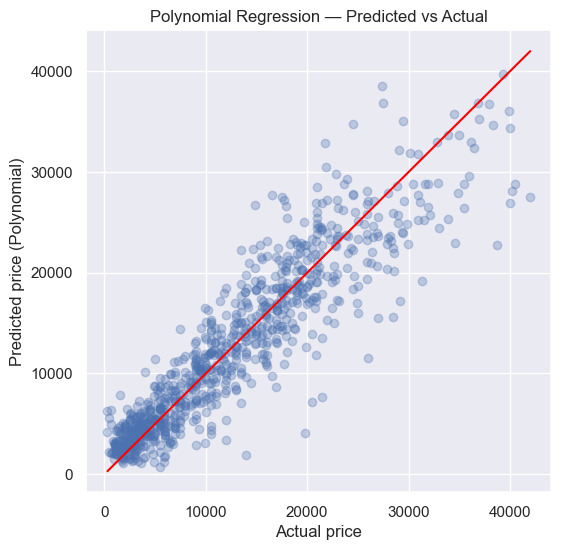

In [59]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_poly, y_pred_poly_test, alpha=0.3)
plt.plot([y_test_poly.min(), y_test_poly.max()],
         [y_test_poly.min(), y_test_poly.max()],
         color='red')

plt.xlabel("Actual price")
plt.ylabel("Predicted price (Polynomial)")
plt.title("Polynomial Regression — Predicted vs Actual")
plt.show()

**Results (Polynomial Regression, degree=2)**

- **R² = 0.84 (test) / 0.85 (train):** The model captures some non-linear relationships between numerical features and price, but does not outperform standard multiple regression.
- **MAE and RMSE:** Slightly worse than the multiple linear model — adding polynomial terms introduces complexity without real accuracy gains.
- **Very stable:** R² (train) ≈ R² (test) — no overfitting, which is notable.
- **Categorical columns excluded:** With `degree=2`, including one-hot-encoded categorical features would generate an unmanageable number of columns. Only numerical features are used here.

**Conclusion:** Polynomial regression doesn't improve accuracy in this case, but provides a robust and stable model with fewer input features. It is also the only model in this notebook whose predicted-vs-actual plot shows **no negative price predictions**.

---

**Additional experiments and observations**

- **Without removing outliers:** R² = 0.80 (test) / 0.81 (train)
- **Removing only cars with >900,000 km:** Nearly identical results to removing all outliers
- **Fastest model of all** — expected, since it only uses numerical features
- **Most robust model** — smallest gap between train and test R²
- **Without `is_automatic`:** R² drops to 0.83/0.83
- **`degree=1`** → 0.77/0.78 | **`degree=2`** → 0.84/0.85 | **`degree=3`** → 0.80/0.81 | **`degree=4`** → 0.56/0.58 (severe overfitting)
- **`KNNImputer`** yields slightly worse results: R² = 0.83/0.84
- **`is_professional`** slightly improves the model — worth keeping.

## Extra: Avoiding Negative Price Predictions

As seen in the predicted-vs-actual plots, all models except the polynomial one can produce **negative price predictions** for some inputs. This is a known limitation of unconstrained linear models.

One effective fix is **`TransformedTargetRegressor`** with a log transformation. The idea: instead of learning `price` directly, the model learns `log(price + 1)`. Since logarithms are always positive, and the inverse transformation `exp()` is also always positive, predictions are guaranteed to be non-negative.

This approach also tends to:
- Reduce price distribution skewness
- Improve overall model performance
- Produce a more stable model

It has been tested and works well for this dataset. It is presented here as a bonus observation rather than integrated into the models above — log-transforming the target changes the interpretation of all metrics (MAE, RMSE) and deserves deeper analysis before being adopted in practice.

```python
from sklearn.compose import TransformedTargetRegressor

reg = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p,
    inverse_func=np.expm1
)
reg.fit(X_train, y_train)
```

# Final Conclusion

The best-performing model for this dataset is **Ridge Regression**.

| Model | R² (test) | R² (train) | Notes |
|---|---|---|---|
| Multiple Linear Regression | 0.862 | 0.902 | Strong baseline, slight overfitting |
| LASSO | 0.858 | 0.894 | Slightly worse, performs feature selection |
| **Ridge** | **0.864** | **0.895** | Best generalization, most robust |
| Polynomial (degree=2) | 0.840 | 0.850 | Stable, no negative predictions, lower accuracy |

**Why Ridge?**
- Highest R² on the test set (0.864)
- Smallest train-test gap among the linear models → better generalization, less overfitting
- LASSO performs slightly worse across all metrics
- The polynomial model adds complexity without matching the linear models' accuracy

> **If only numerical features are available** (no brand/model info), the polynomial model (degree=2) is the best alternative — it delivers solid performance with far fewer inputs.

---

I hope this notebook helped you learn something new about machine learning and data science!

Throughout the notebook you will find several starting points — different preprocessing choices, models, and hyperparameters — that you can tweak and experiment with to try to get even better results. Feel free to modify whatever you like and make it your own.

If you have any questions, feel free to reach out at **21alexrodri@gmail.com**